# 11b · Self-selected ad exposure, on real data — the Criteo experiment (IV · CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**
> First run downloads the 311 MB Criteo file into `~/.cache/cmp` (one-time; a seeded subsample is
> cached after that).

**The business decision.** Notebook [11](11_endogenous_exposure_iv.ipynb)'s story, at industrial
scale and with nothing simulated: **13.98 million real users** from Criteo's advertising
incrementality tests (Diemert et al. 2018). Users who *saw* an ad visit the advertiser at hugely
elevated rates — but the ad system *chose* whom to show ads to (bids, browsing, auctions), so
exposure is **self-selected** and the naive comparison credits the ad with intent that was already
there. We want the true causal effect of exposure, to set the **budget cap per exposed user**.

### Why this dataset is a gift for IV

Criteo's incrementality tests randomize **eligibility**: a random 15% of users are locked out of
the campaign entirely. That randomized `treatment` flag is a textbook **encouragement instrument** — we randomize a *nudge*
toward exposure (eligibility), not exposure itself — for the self-selected `exposure`:

- **Relevance** — eligibility moves exposure (3.6% of eligible users end up exposed) — *testable*,
  first-stage F below;
- **Exclusion** — being *silently eligible* does nothing to your visiting behaviour unless an ad
  actually reaches you — *untestable*, stress-tested in Step 6;
- **Exogeneity** — eligibility is randomized by the test infrastructure — *holds by design*;
- **Monotonicity, for free**: ineligible users are **never** exposed (one-sided noncompliance), so
  "defiers" are impossible *by construction*, not by assumption — and the **LATE** (local average treatment effect —
  the effect for exactly the users the instrument moves) specializes to the **effect on the exposed**
  (ATT), exactly the population a budget cap is about.

### What replaces the simulator's planted truth

Two real-data anchors. **(a)** At n = 13.98M the design-based **Wald estimate** (intent-to-treat ÷
first stage) is essentially free of sampling noise — we compute it once on the full file and grade
every subsample estimate against it. **(b)** The features let us *photograph the confounding
itself*: f0–f11 are balanced across the randomized arms but sharply imbalanced across exposure —
the self-selection nb11 could only simulate, measured.

In [1]:
import os, warnings, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import causalpy as cp
from cmp import data, estimators as est, plots
plots.use_style()

FAST = os.environ.get("CMP_FAST", "1") == "1"
N_ARM = 15_000 if FAST else 100_000     # rows per randomized arm in the working subsample
N_FIT = 30_000 if FAST else 100_000     # rows the Bayesian IV actually fits (posterior cost ~ n)
COST = 0.20                              # assumed cost per exposed user (€) — swept in step 6
VALUE_PER_VISIT = 1.0                    # assumed value of one incremental visit (€) — swept in step 6
N_EXP_QUARTER = 1_000_000                # assumed exposures bought per quarter — scales step 6's cap gap to campaign euros
print(f"FAST={FAST}  subsample={2 * N_ARM:,} rows  Bayesian fit on {N_FIT:,} rows")

FAST=True  subsample=30,000 rows  Bayesian fit on 30,000 rows


## 2 · Load the real data (what replaces "simulate a ground truth")

`cmp.data.load_criteo_uplift()` downloads the full file once, then caches a **seeded, balanced
subsample** — `N_ARM` rows from each randomized arm. Balancing the 85/15 arms is legitimate
*because* the sampling key is the randomized flag itself (both the ITT and the first stage are
conditional on `treatment`, so selecting on it biases nothing) and roughly doubles precision per
row. The **data card**:

| fact | value |
|---|---|
| population | 13,979,592 users, assembled from several incrementality tests |
| randomization | `treatment` = eligible to be targeted (85%) vs locked out (15%) |
| self-selection | `exposure` = actually saw an ad: **3.6% of eligible, 0.0% of ineligible** |
| outcomes | `visit` (4.7% base) — primary; `conversion` (0.29%) — secondary, rarer & noisier |
| features | f0–f11, anonymized dense floats (used for balance checks, not needed for IV) |
| full-data anchor | Wald LATE on visit **+28.7 pp**, on conversion **+3.2 pp** (computed below) |

**Provenance check (cheap hygiene).** The card's base rates are the published ones: Criteo's
dataset release reports 13,979,592 rows, an 85/15 eligibility split, and ≈4.7% visit / ≈0.29%
conversion base rates (Diemert et al. 2018 — full citation in §7), matching what the loader
serves. So we are analyzing the dataset the paper describes, not a truncated or corrupted
download — reconcile any loader against its source paper before believing anything downstream.
The full-file anchor below remains the primary yardstick; this row is provenance, not validation.

The one modelling accommodation, inherited from nb11 and disclosed the same way: outcome and
exposure are 0/1, and CausalPy's joint-MvNormal IV treats both equations as **linear-probability**
(Gaussian) — fine for the point estimate and the error correlation ρ, so those are what we read.

In [2]:
df = data.load_criteo_uplift(n_per_arm=N_ARM, seed=11)
anchor = data.criteo_full_anchor()          # exact ITT / first stage / Wald on all 13.98M rows
z = df["treatment"].values; d = df["exposure"].values; y = df["visit"].values
Fstat = est.first_stage_F(df["treatment"], df["exposure"])
print(f"subsample: {len(df):,} rows ({int(z.sum()):,} eligible / {int((1 - z).sum()):,} locked out)")
print(f"P(exposed | eligible) = {d[z == 1].mean():.4f}   P(exposed | locked out) = {d[z == 0].mean():.4f}\n"
      f"  -> one-sided noncompliance, first-stage F = {Fstat:,.0f}")
print(f"visit rate: {y[z == 0].mean():.4f} locked out vs {y[z == 1].mean():.4f} eligible "
      f"(ITT {100 * (y[z == 1].mean() - y[z == 0].mean()):+.2f} pp)")
print(f"full-data anchor (n=13.98M): ITT {100 * anchor['visit']['itt']:+.3f} pp, first stage "
      f"{anchor['first_stage']:.4f},\n"
      f"  Wald LATE {100 * anchor['visit']['wald_late']:+.1f} pp on visit")
df[["f0", "f1", "f6", "treatment", "exposure", "visit", "conversion"]].head().round(2)  # 3 of the 12 features

subsample: 30,000 rows (15,000 eligible / 15,000 locked out)
P(exposed | eligible) = 0.0372   P(exposed | locked out) = 0.0000
  -> one-sided noncompliance, first-stage F = 580
visit rate: 0.0344 locked out vs 0.0497 eligible (ITT +1.53 pp)
full-data anchor (n=13.98M): ITT +1.034 pp, first stage 0.0360,
  Wald LATE +28.7 pp on visit


,f0,f1,f6,treatment,exposure,visit,conversion
0,22.030001,10.06,-7.30,0.0,0.0,0.0,0.0
1,23.740000,10.06,-5.12,0.0,0.0,0.0,0.0
2,12.620000,10.06,0.29,1.0,0.0,0.0,0.0
3,25.770000,10.06,-5.58,0.0,0.0,0.0,0.0
4,23.370001,10.06,-4.60,1.0,0.0,0.0,0.0


## 3 · Identify — a real instrument, and the confounding made visible

Exposure is endogenous: the ad system bids more for users who browse more, and browsing predicts
visiting with or without ads. The instrument's three conditions are laid out in the header; before
photographing the confounding, here is the estimand in symbols — because "the LATE specializes to
the ATT" is this notebook's central identification claim, and it deserves a derivation, not a bullet.

### The estimand: ITT, first stage, Wald — and why Wald = LATE = ATT here

Notation as in notebook 11 — $Z$ the instrument, $X$ the endogenous exposure, $Y$ the outcome.
(The print-outs' "Z→D" arrow is the same first stage: $D$, for "dose", is the econometrics
alias for our $X$.) With $Z_i \in \{0,1\}$ the randomized eligibility, $X_i \in \{0,1\}$ actual
exposure, $Y_i \in \{0,1\}$ a visit, potential outcomes $Y_i(x)$ and potential exposures $X_i(z)$,
the three observed quantities are

$$
\text{ITT} \;=\; \mathbb{E}[Y \mid Z{=}1] - \mathbb{E}[Y \mid Z{=}0], \qquad
\pi \;=\; \mathbb{E}[X \mid Z{=}1] - \mathbb{E}[X \mid Z{=}0], \qquad
\hat\beta_{\text{Wald}} \;=\; \frac{\text{ITT}}{\pi}.
$$

Why the ratio is causal: write $Y_i = Y_i(0) + X_i\,\big(Y_i(1) - Y_i(0)\big)$ and take
expectations given $Z$. Randomization (exogeneity) plus exclusion make
$\mathbb{E}[Y(0) \mid Z{=}1] = \mathbb{E}[Y(0) \mid Z{=}0]$, so the $Y(0)$ terms cancel from
the ITT and only instrument-driven exposure survives:

$$
\text{ITT} \;=\; \mathbb{E}\big[(Y(1)-Y(0))\,X \mid Z{=}1\big]
\;-\; \mathbb{E}\big[(Y(1)-Y(0))\,X \mid Z{=}0\big].
$$

In this design the second term is exactly **zero**: locked-out users are never exposed —
$P(X{=}1 \mid Z{=}0) = 0$, printed as 0.0000 in step 2, a fact of the serving infrastructure,
not a sample accident. So, with $\pi = P(X{=}1 \mid Z{=}1)$,

$$
\hat\beta_{\text{Wald}}
\;=\; \frac{\mathbb{E}\big[(Y(1)-Y(0))\,X \mid Z{=}1\big]}{P(X{=}1 \mid Z{=}1)}
\;=\; \mathbb{E}\big[\,Y(1)-Y(0) \mid X{=}1\,\big]
\;=\; \text{the ATT of the exposed}
$$

(Bloom 1984) — the conditioning on $Z{=}1$ drops because *every* exposed user is an eligible
user. In the general two-sided case this ratio is Imbens–Angrist's complier LATE and needs
monotonicity (no defiers) as an *assumption*; one-sided noncompliance delivers it by
construction, and the "compliers" are literally the exposed. A **defier** would be a user who gets
exposed *only because* they were locked out — logically impossible here, since locked-out users are
never exposed at all, which is exactly why monotonicity holds by construction. On the full file the pieces are
$\text{ITT} \approx +1.03$ pp and $\pi \approx 0.0360$, giving
$\hat\beta_{\text{Wald}} \approx +28.7$ pp — the anchor every subsample estimate below is
graded against.

### The confounding, photographed

And here is the part a simulator can never show. If randomization worked, the twelve user features must be
**flat across the arms** (any imbalance would impeach the instrument's exogeneity). If exposure is
truly self-selected, the same features must be **skewed across exposure**. Both facts are checkable
— one chart, two stories:

- across **eligibility** (randomized): standardized mean differences ≈ 0 → the instrument is clean;
- across **exposure** (chosen by the auction): large SMDs → the exposed *were different people
  before any ad effect* — the very confounder nb11 called `engagement`, photographed in real data.

This is also why no regression on f0–f11 could rescue the naive estimate: these are only the
*observable* shadows of targeting; the auction also used signals not in the file (the unmeasured
confounder), which is precisely the case where notebook 05's adjustment toolkit surrenders and IV
takes over.

max |SMD| across eligibility: 0.080  (randomization holds)
max |SMD| across exposure:    1.963  (the exposed were different people to begin with)


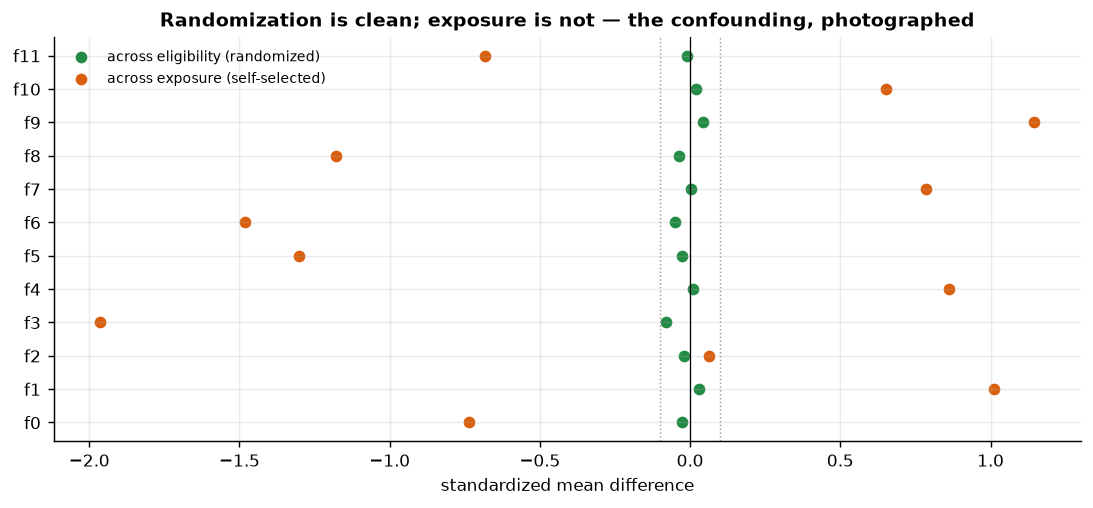

In [3]:
feats = [f"f{i}" for i in range(12)]
def smd(frame, flag_col):
    a = frame[frame[flag_col] == 1]; b = frame[frame[flag_col] == 0]
    sd = np.sqrt((frame[feats].var())).replace(0, np.nan)
    return ((a[feats].mean() - b[feats].mean()) / sd).values

smd_z = smd(df, "treatment")                          # randomized -> should be ~0
smd_d = smd(df[df.treatment == 1], "exposure")        # self-selected -> should be skewed

fig, ax = plt.subplots(figsize=(8.5, 4))
ypos = np.arange(len(feats))
ax.scatter(smd_z, ypos, color=plots.GREEN, s=30, label="across eligibility (randomized)")
ax.scatter(smd_d, ypos, color=plots.ORANGE, s=30, label="across exposure (self-selected)")
ax.axvline(0, color="k", lw=0.7); ax.axvline(0.1, color=plots.GREY, ls=":", lw=0.8); ax.axvline(-0.1, color=plots.GREY, ls=":", lw=0.8)
ax.set_yticks(ypos); ax.set_yticklabels(feats); ax.set_xlabel("standardized mean difference")
ax.set_title("Randomization is clean; exposure is not — the confounding, photographed")
ax.legend(frameon=False, fontsize=8); fig.tight_layout()
print(f"max |SMD| across eligibility: {np.nanmax(np.abs(smd_z)):.3f}  (randomization holds)")
print(f"max |SMD| across exposure:    {np.nanmax(np.abs(smd_d)):.3f}  (the exposed were different people to begin with)")

## 4 · Estimate — OLS, the Wald ladder, and Bayesian IV

Same ladder as nb11, every rung now a real number:

- **OLS / naive** — the **as-treated** comparison (split users by exposure *received*, not by randomized
  eligibility): visit rate of exposed minus unexposed. This is the third rung of the ITT / LATE / as-treated
  triangle from nb11, and the one self-selection contaminates — the number an attribution dashboard
  reports, inflated by targeting;
- **Reduced form** (eligibility → visit) — this *is* the ITT of §3 — and **first stage**
  (eligibility → exposure) — this *is* $\pi$: both clean, both tiny (the encouragement is randomized but
  weak *per user*), so their **ratio** is exactly the Wald $\text{ITT}/\pi$ derived above, the honest
  per-exposure effect;
- **Bayesian IV** (CausalPy): the same ratio estimated jointly, with the endogeneity ρ estimated
  rather than assumed away, and weakly-informative priors (nb11's gotcha: CausalPy's default priors
  centre on the **two-stage least squares (2SLS)** point estimate — the classical frequentist IV fit —
  with `sigma=1`, which would pin the Bayesian posterior right on top of it and yield an overconfident
  band). The fit uses `N_FIT` rows — NUTS (the Hamiltonian sampler underneath) cost scales with n, and Step 5 grades this subsample posterior against the 13.98M-row anchor
  to show what the smaller n costs us.

**The third rung's model, in symbols** — the same joint Gaussian as nb11's, with $X$ = exposure
and $Y$ = visit:

$$
\begin{pmatrix} X_i \\ Y_i \end{pmatrix} \sim
\mathcal N_2\!\left( \begin{pmatrix} b_0 + \pi Z_i \\ \beta_0 + \beta X_i \end{pmatrix},\;
\Sigma \right), \qquad
\Sigma = \begin{pmatrix} \sigma_X^{2} & \rho\,\sigma_X \sigma_Y \\
\rho\,\sigma_X \sigma_Y & \sigma_Y^{2} \end{pmatrix},
$$

where $\beta$ is the causal effect the budget cap needs and the off-diagonal $\rho$ **is** the
endogeneity: the correlation between the exposure-equation and visit-equation errors that hidden
intent induces and that the naive comparison ignores. The model *estimates* $\rho$ instead of
assuming it zero; a positive $\rho$ is the self-selection signature. Two reading notes: $\rho$ is
small here even at full fit size — visits are rare events, so even strong targeting induces only a
modest error *correlation* — and a small subsample may not resolve its sign at all. The naive-vs-IV
gap, not $\rho$'s magnitude, is where the bias shows.
Priors: $b_0, \pi, \beta_0, \beta \sim \mathcal N(0, 50^{2})$ — that is the `sigmas: [50, 50]`
passed in the code, the weakly-informative override of CausalPy 0.8.1's default priors, which
centre on the 2SLS point with $\sigma = 1$ and yield a band roughly 3× too narrow (nb11
demonstrates that band excluding its planted truth; same model, same library version here, so the
gotcha transfers verbatim) — and a mild **LKJ** prior on the error correlation,
$\Sigma \sim \text{LKJCholeskyCov}(\eta = 2)$ ($\eta=2$ gently pulls $\rho$ toward 0, so the data has
to argue for endogeneity).

One upgrade on the linear-probability disclosure: because $Z$ and $X$ are both binary, both
**conditional means** above are *saturated* — a linear function of a binary regressor can match
$\mathbb{E}[X \mid Z]$ and $\mathbb{E}[Y \mid X]$ exactly — so the LPM approximation lives
entirely in the Gaussian *likelihood*, not in the mean structure. That is precisely why the point
estimate and $\rho$ are the trustworthy read-outs, and the equation-level posterior widths are
the thing not to over-read.

> **Reading the sampler's health check (the `IV convergence:` line below, and any PyMC warning beside it).** Three numbers say whether the MCMC sampler — the algorithm drawing from the posterior — converged: **R-hat** compares the variance *within* each chain to the variance *across* chains (1.00 is perfect, **≤ 1.01 is the usual pass bar**); **ESS** (effective sample size) is how many *independent* draws our autocorrelated chains are worth (a few hundred is ample for a posterior mean or interval); **divergences** are steps where the sampler broke down and silently distrusts that region (**you want 0**). Under this notebook's FAST profile the chains are deliberately short (200 draws over 2 chains), so R-hat can drift to ≈1.02 and PyMC may print an ESS / "problems during sampling" notice — a benign small-draw-count artifact that a FULL run (4 chains, more draws) clears. The point estimate and its interval are stable regardless, which the disjoint-fold check (Step 5) and the 13.98M-row anchor confirm.

In [4]:
naive = y[d == 1].mean() - y[d == 0].mean()
reduced = y[z == 1].mean() - y[z == 0].mean()
first = d[z == 1].mean() - d[z == 0].mean()
wald = reduced / first

df_fit = df.iloc[:N_FIT]                      # pre-shuffled cache -> a random ~50/50 slice
result = est.iv(df_fit, "exposure ~ 1 + treatment", "visit ~ 1 + exposure",
                instrument_col="treatment", treatment_col="exposure", outcome_col="visit",
                fast=FAST, priors={"mus": [0, 0], "sigmas": [50, 50], "eta": 2, "lkj_sd": 2})
iv_post = result.idata.posterior["beta_z"].sel(covariates="exposure").values.ravel()
print(f"OLS / naive (exposed vs not)   {100 * naive:+.1f} pp")
print(f"Reduced form (Z->Y) {100 * reduced:+.2f} pp  ÷  first stage (Z->D) {first:.4f}  =  Wald {100 * wald:+.1f} pp")
print(f"Bayesian IV ({N_FIT:,} rows)    {100 * iv_post.mean():+.1f} pp   90% credible interval "
      f"[{100 * np.quantile(iv_post, 0.05):+.1f}, {100 * np.quantile(iv_post, 0.95):+.1f}] pp")
print(f"full-data anchor (13.98M)      {100 * anchor['visit']['wald_late']:+.1f} pp")
print(f"IV convergence: {est.convergence_report(result.idata)['summary']}")

# endogeneity rho — same extraction as nb11 (CausalPy fits a 2x2 LKJ error covariance)
_post = result.idata.posterior
_rho = None
try:
    if "chol_cov_corr" in _post:
        _rho = _post["chol_cov_corr"].values[..., 0, 1].ravel()
    elif "chol_cov" in _post:
        _ch = np.asarray(_post["chol_cov"].values)
        _flat = _ch.reshape(-1, *_ch.shape[2:])
        def _rho_from(x):
            x = np.asarray(x)
            if x.shape == (2, 2):
                L = x
            elif x.size == 3:
                L = np.array([[x[0], 0.0], [x[1], x[2]]])
            else:
                return np.nan
            S = L @ L.T
            return S[0, 1] / np.sqrt(S[0, 0] * S[1, 1])
        _rho = np.array([_rho_from(x) for x in _flat])
except Exception as _e:
    print(f"(could not extract endogeneity rho: {_e})")
if _rho is not None and np.isfinite(_rho).any():
    _rho = _rho[np.isfinite(_rho)]
    print(f"estimated endogeneity rho = {_rho.mean():+.2f} [90% {np.quantile(_rho, 0.05):+.2f}, "
          f"{np.quantile(_rho, 0.95):+.2f}] — positive rho is the self-selection: the same hidden "
          f"leanings push a user into both exposure and visiting")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [beta_t, beta_z, chol_cov]


Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 37 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


OLS / naive (exposed vs not)   +37.2 pp
Reduced form (Z->Y) +1.53 pp  ÷  first stage (Z->D) 0.0372  =  Wald +41.2 pp
Bayesian IV (30,000 rows)    +40.6 pp   90% credible interval [+31.0, +50.9] pp
full-data anchor (13.98M)      +28.7 pp
IV convergence: max r-hat 1.020 - min ESS 152 - divergences 0
estimated endogeneity rho = -0.02 [90% -0.09, +0.04] — positive rho is the self-selection: the same hidden leanings push a user into both exposure and visiting


## 5 · Validate — against 13.98 million rows

No planted truth, but a better yardstick than most real projects ever get: the full-file **Wald
anchor**, whose own sampling noise at n = 13.98M is negligible for our purposes. Three checks, plus
the star exhibit:

1. **Anchor recovery.** The subsample Bayesian IV's 90% interval should cover the anchor (+28.7 pp),
   and its point should sit within a couple of pp — that is the real-data analogue of nb11's
   "recover the €15." (Expect the pass at the full working size; on a small FAST slice the Wald
   ratio's SE is several pp, so the interval can sit an SE or two off the anchor — subsampling
   noise that check 3 prices, not a failed identification.)
2. **Internal consistency.** Wald ≈ Bayesian IV on the same rows (they are the same identification
   strategy, estimated two ways); a gap would flag a modelling artefact, not a causal discovery.
3. **Disjoint-subsample stability** — nb11's multi-seed loop, real-data edition: we can't refit on
   fresh *worlds*, but 13.98M rows let us refit on fresh *samples*. Split the working subsample
   into disjoint folds, compute each fold's Wald ± normal CI, and check spread and anchor coverage.
4. **The OLS − IV gap *is* the measured self-selection bias**: the euros an attribution dashboard
   would over-credit to the ad. On the full file the gap is deterministic: naive ≈ +37.9 pp
   vs the +28.7 pp anchor — the dashboard number runs ≈32% too big, on 13.98 million real
   users. The print below re-measures the same gap on the working subsample, where it also
   carries the subsample's Wald noise (priced by the fold check).

**The fold CIs, derived (and the F-statistic's real job).** Each fold's interval is a
**delta-method** CI for a ratio. Writing $\hat\beta = \widehat{\text{ITT}}/\hat\pi$ and
propagating both numerator and denominator noise,

$$
\operatorname{Var}\big(\hat\beta\big) \;\approx\;
\frac{1}{\hat\pi^{2}}\operatorname{Var}\big(\widehat{\text{ITT}}\big)
\;+\; \frac{\hat\beta^{2}}{\hat\pi^{2}}\operatorname{Var}\big(\hat\pi\big)
\;-\; \frac{2\hat\beta}{\hat\pi^{2}}\operatorname{Cov}\big(\widehat{\text{ITT}},\,\hat\pi\big).
$$

The folds keep only the first term, $\text{SE}(\hat\beta) \approx
\text{SE}(\widehat{\text{ITT}})/\hat\pi$. The licence to drop the other two is the strong first
stage: the *relative* noise of $\hat\pi$ is $1/\sqrt{F}$ (single-regressor first stage, so the first-stage
$t = \hat\pi/\text{SE}(\hat\pi)$ and $F = t^{2}$, which makes $1/\sqrt{F}$ *exactly* the relative
noise $\text{SE}(\hat\pi)/\hat\pi$) — a few percent here, versus
double-digit relative noise in a fold-level ITT — so the dropped terms move the SE by only a few
percent. The code prints the full three-term SE next to the shortcut, so the approximation is
audited rather than asserted. This is what a large $F$ actually buys: permission to treat the
ratio's denominator as (nearly) known.


anchor recovery: 90% interval [+31.0, +50.9] pp MISSES the 13.98M-row anchor (+28.7 pp)
internal consistency: subsample Wald +41.2 vs Bayesian +40.6 pp
self-selection bias, measured against the anchor: naive +37.2 -> causal +28.7 pp (+8.5 pp of pure targeting, ~29% inflation; this slice's own IV: +40.6 pp)


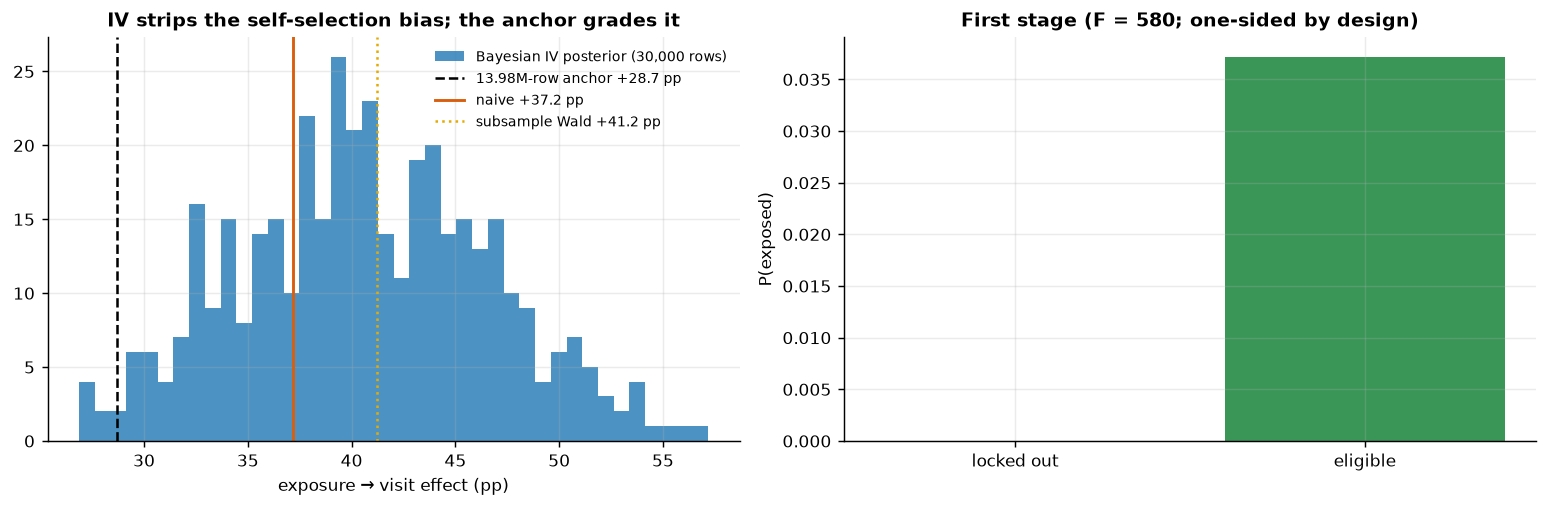

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(100 * iv_post, bins=40, color=plots.BLUE, alpha=0.85, label=f"Bayesian IV posterior ({N_FIT:,} rows)")
ax[0].axvline(100 * anchor["visit"]["wald_late"], color="k", ls="--", lw=1.4,
              label=f"13.98M-row anchor {100 * anchor['visit']['wald_late']:+.1f} pp")
ax[0].axvline(100 * naive, color=plots.ORANGE, lw=1.6, label=f"naive {100 * naive:+.1f} pp")
ax[0].axvline(100 * wald, color=plots.GOLD, ls=":", lw=1.4, label=f"subsample Wald {100 * wald:+.1f} pp")
ax[0].set_xlabel("exposure → visit effect (pp)"); ax[0].legend(frameon=False, fontsize=8)
ax[0].set_title("IV strips the self-selection bias; the anchor grades it")
fs_bar = [d[z == 0].mean(), d[z == 1].mean()]
ax[1].bar(["locked out", "eligible"], fs_bar, color=[plots.GREY, plots.GREEN], alpha=0.9)
ax[1].set_ylabel("P(exposed)"); ax[1].set_title(f"First stage (F = {Fstat:,.0f}; one-sided by design)")
fig.tight_layout()

lo, hi = np.quantile(iv_post, [0.05, 0.95])
covers = lo <= anchor["visit"]["wald_late"] <= hi
print(f"anchor recovery: 90% interval [{100 * lo:+.1f}, {100 * hi:+.1f}] pp "
      f"{'COVERS' if covers else 'MISSES'} the 13.98M-row anchor ({100 * anchor['visit']['wald_late']:+.1f} pp)")
print(f"internal consistency: subsample Wald {100 * wald:+.1f} vs Bayesian {100 * iv_post.mean():+.1f} pp")
a_w = anchor["visit"]["wald_late"]
print(f"self-selection bias, measured against the anchor: naive {100 * naive:+.1f} -> causal {100 * a_w:+.1f} pp "
      f"({100 * (naive - a_w):+.1f} pp of pure targeting, ~{(naive - a_w) / a_w:.0%} inflation; "
      f"this slice's own IV: {100 * iv_post.mean():+.1f} pp)")

**How to read this.** *Left* — four vertical markers tell the story. The **orange** line is the
naive exposed-vs-unexposed gap: the attribution-dashboard number, the one everything else should
sit below. The **blue** histogram is the Bayesian IV posterior for the same causal question; the
**gold dotted** line is the subsample Wald (same identification, frequentist arithmetic); the
**dashed black** line is the 13.98M-row anchor (+28.7 pp). The horizontal distance from the orange
line down to the anchor *is* the self-selection premium, measured: on the full file ≈9 pp of the
≈38 pp naive "effect" — roughly a third — is intent the exposed users already had. The printed
checks grade the rest: the 90% interval covering the anchor is check 1, and posterior mean ≈ Wald
is check 2 (a gap there would flag a modelling artefact, not a causal discovery). (One number to not trip on: the naive gap *printed* here is this subsample's, a touch below the full-file +37.9 pp quoted in the text and Step 5 — same story, different $n$.) One honesty note
before over-reading the blue centre: with a 3.6% exposure rate in the denominator, subsample Wald
ratios are genuinely noisy, so on a small slice the posterior can drift an SE or two from the
anchor — that drift is sampling noise, priced explicitly by the fold chart below, not a broken
instrument. *Right* — the first stage is the design itself, not a diagnostic that happened to
pass: the locked-out bar is exactly zero (one-sided noncompliance — the fact that turned LATE
into ATT in §3) and the eligible bar (≈3.6%) is the entire lever the instrument pulls. $F \gg 10$
is the licence for dividing by it; with a weak first stage the left panel would be meaningless.

fold Walds: mean +40.4 pp, sd 18.7 pp (anchor +28.7); 90% CIs cover the anchor in 83% of folds
the spread is the honest price of subsampling a rare exposure (3.6%) — and why the anchor was computed on all 13.98M rows


delta-method audit: shortcut SE 6.23 pp vs full three-term SE 6.04 pp (+3%); first-stage relative noise 1/sqrt(F) = 4.2% — dropping it is disclosed, not hidden, and errs slightly conservative here


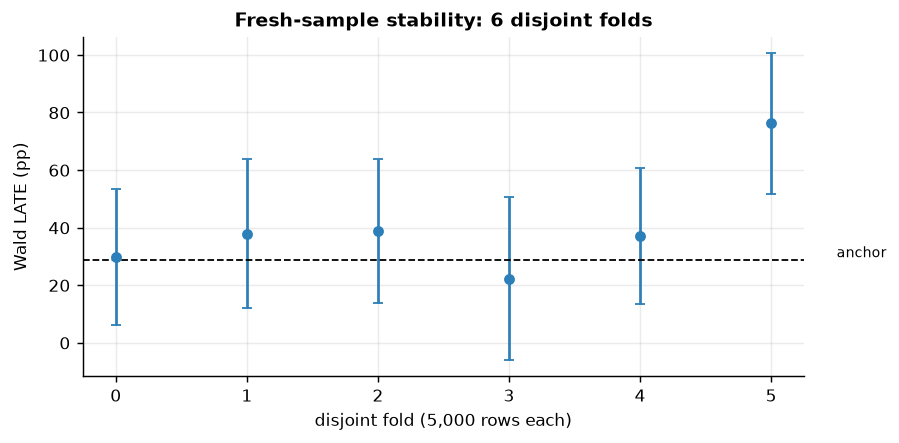

In [6]:
# disjoint-fold stability: nb11's multi-seed recovery, real-data edition (Wald per fold, delta-method CI)
K = 6 if FAST else 8
folds = np.array_split(np.arange(len(df)), K)
rows = []
for k, idx in enumerate(folds):
    dk = df.iloc[idx]
    zk, ek, yk = dk["treatment"].values, dk["exposure"].values, dk["visit"].values
    ittk = yk[zk == 1].mean() - yk[zk == 0].mean()
    fsk = ek[zk == 1].mean() - ek[zk == 0].mean()
    n1, n0 = (zk == 1).sum(), (zk == 0).sum()
    se_itt = np.sqrt(yk[zk == 1].var() / n1 + yk[zk == 0].var() / n0)
    wk, sek = ittk / fsk, se_itt / fsk          # first-stage noise ignored (F >> 10); disclosed
    rows.append({"wald": wk, "lo": wk - 1.645 * sek, "hi": wk + 1.645 * sek})
folds_df = pd.DataFrame(rows)
cover = ((folds_df.lo <= anchor["visit"]["wald_late"]) & (anchor["visit"]["wald_late"] <= folds_df.hi)).mean()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.errorbar(np.arange(K), 100 * folds_df.wald, yerr=100 * (folds_df.wald - folds_df.lo),
            fmt="o", color=plots.BLUE, ms=5, capsize=3)
ax.axhline(100 * anchor["visit"]["wald_late"], color="k", ls="--", lw=1)
ax.text(K - 0.5, 100 * anchor["visit"]["wald_late"] + 1, "anchor", fontsize=8)
ax.set_xlabel(f"disjoint fold ({len(folds[0]):,} rows each)"); ax.set_ylabel("Wald LATE (pp)")
ax.set_title(f"Fresh-sample stability: {K} disjoint folds"); fig.tight_layout()
print(f"fold Walds: mean {100 * folds_df.wald.mean():+.1f} pp, sd {100 * folds_df.wald.std():.1f} pp "
      f"(anchor {100 * anchor['visit']['wald_late']:+.1f}); 90% CIs cover the anchor in "
      f"{cover:.0%} of folds")
print("the spread is the honest price of subsampling a rare exposure (3.6%) — and why the anchor "
      "was computed on all 13.98M rows")

# delta-method audit (whole working subsample): the folds' shortcut SE vs the full three-term SE
n1s, n0s = (z == 1).sum(), (z == 0).sum()
v_itt = y[z == 1].var() / n1s + y[z == 0].var() / n0s
v_pi = d[z == 1].var() / n1s + d[z == 0].var() / n0s
c_ip = np.cov(y[z == 1], d[z == 1])[0, 1] / n1s + np.cov(y[z == 0], d[z == 0])[0, 1] / n0s
se_short = np.sqrt(v_itt) / first
se_full3 = np.sqrt(v_itt + wald ** 2 * v_pi - 2 * wald * c_ip) / first
print(f"delta-method audit: shortcut SE {100 * se_short:.2f} pp vs full three-term SE "
      f"{100 * se_full3:.2f} pp ({(se_short - se_full3) / se_full3:+.0%}); first-stage relative "
      f"noise 1/sqrt(F) = {1 / np.sqrt(Fstat):.1%} — dropping it is disclosed, not hidden, "
      f"and errs slightly conservative here")

## 6 · Decide, in euros — the budget cap, and the exclusion stress test

The cap logic of nb11, with real numbers: an exposed user visits with **≈ +29 pp** extra
probability (the 13.98M-row anchor: +28.7 pp), so at an assumed **€1 value per incremental
visit** an exposure is worth ≈ €0.29 — and the *naive* number (full-file exposed-vs-unexposed
gap, ≈ +37.9 pp) would have priced it at ≈ €0.38. The decision rule: **BUY exposure while
P(value × LATE > cost) ≥ 0.9**; sweeping the cost turns that into the **maximum viable price per
exposed user**. Both business inputs are assumptions and get swept: the €1 visit-value scales the
cap linearly, and the secondary `conversion` outcome gives an independent cap for a
margin-per-conversion framing.

**The exclusion stress test.** The lockout is silent, but eligibility could still leak around the
`exposure` flag — e.g. eligible users win *other* auctions differently, or "exposed" mislabels a
below-the-fold impression. As in nb11: give eligibility a hypothetical direct effect δ on visits,
correct the reduced form, and find the δ that would flip the BUY.

**The rule, the cap, and the stress test, in symbols.** With $v$ the value per incremental visit,
$c$ the cost per exposed user, and $\beta^{(s)}$ the posterior draws of the exposure effect, the
decision rule and the two prices the sweep reads off are

$$
\text{BUY while } P\big(v\,\beta > c\big) \ge 0.9;
\qquad
c^{*} = v\,q_{0.10}(\beta), \qquad c_{50} = v\,q_{0.50}(\beta),
$$

where $q_{p}(\beta)$ is the posterior $p$-quantile. Sweeping $c$ against a fixed posterior just
walks its quantile function — $P(v\beta > c) \ge 0.9 \iff c \le v\,q_{0.10}(\beta)$ — so the
budget cap $c^{*}$ *is* a posterior quantile denominated in euros, $c_{50}$ is the coin-flip
price, and the cap a dashboard would set is $v\,\hat\beta_{\text{naive}}$. For the exclusion
stress: if eligibility leaks a direct effect $\delta$ (in visit probability) around exposure, the
honest reduced form is $\text{ITT} - \delta$, so the corrected effect and the flip threshold are

$$
\beta(\delta) = \frac{\text{ITT} - \delta}{\pi};
\qquad
v\,\beta(\delta) > c \;\iff\; \delta < \delta^{*} = \text{ITT} - \frac{c\,\pi}{v}.
$$

The flip threshold $\delta^{*}$ has a closed form — no grid search needed — and the code below
prints it next to the grid scan of the third panel, so the two agree in front of you (up to the
grid's resolution). Note $\beta(\delta)$ re-solves the ratio at point estimates: carry the
posterior interval's width alongside it when briefing the cap, as in nb11.


at €0.20/exposed user and €1.00/visit: net €+0.21, P(pays) = 1.00
  -> BUY (to the exposed margin)
budget cap: clears the 90% bar up to €0.33/exposed user; a coin flip at €0.40
  — the naive number would have set the cap at €0.37 against the
  anchor's causal €0.29: 29% too high
conversion framing (secondary): full-data anchor LATE +3.20 pp
  -> at €40 margin/conversion an exposure is worth ~€1.28; the subsample
  pins it only to +1.79 pp (90% CI [-0.77, +4.36] pp
  -> €-0.31 to €+1.74) — at a 0.29% base rate this rung is honestly
  noisy; re-derive with the firm's own margin
exclusion stress: the BUY at €0.20 survives until eligibility's direct effect
  exceeds δ ≈ 0.80 pp — 52% of the whole reduced form (+1.53 pp)
  would have to bypass exposure
  closed form agrees: delta* = ITT - c·π/v = 0.79 pp (grid scan: 0.80 pp)
campaign scale: the naive cap embeds €0.08/exposure of pure targeting premium
  (naive €0.37 vs causal anchor €0.29); at 1,000,000 exposures/quarter
  that is ≈ €84,660

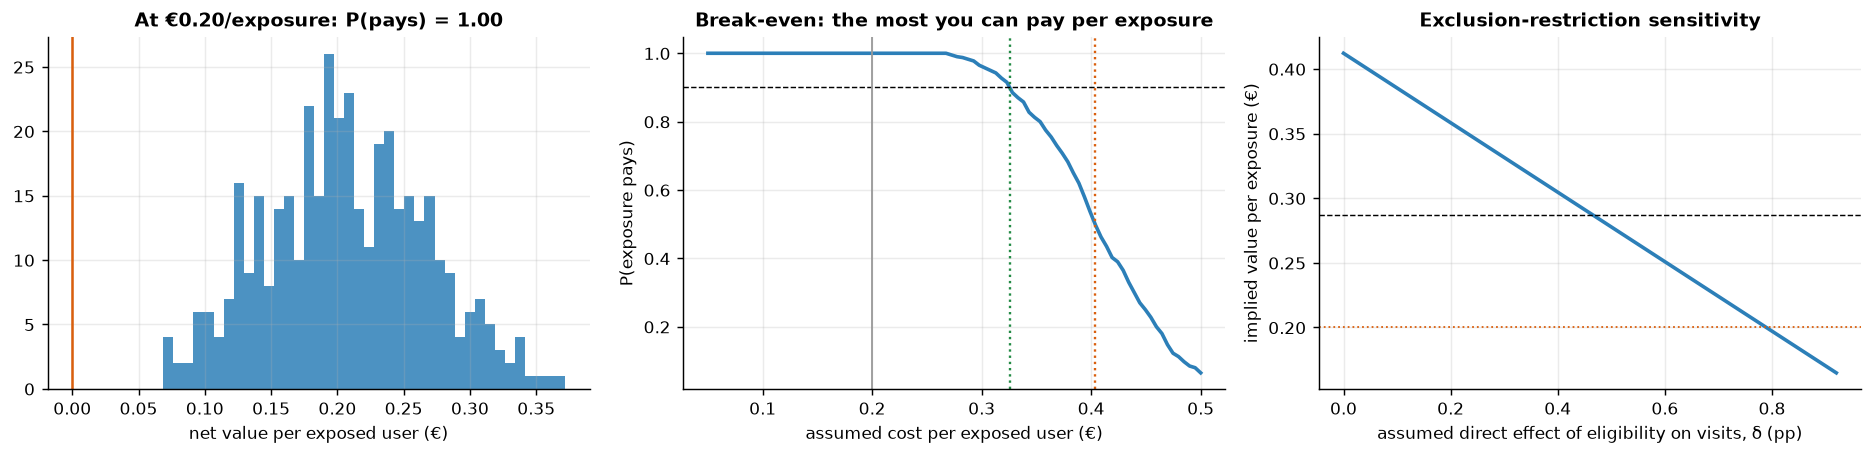

In [7]:
value_post = VALUE_PER_VISIT * iv_post                  # € per exposed user
net = value_post - COST; p_worth = float((net > 0).mean())
costs = np.linspace(0.05, 0.50, 90)
p_pays = np.array([(value_post > c).mean() for c in costs])
c90 = float(np.quantile(value_post, 0.10)); c50 = float(np.median(value_post))
deltas = np.linspace(0, reduced * 0.6, 25)
corrected = VALUE_PER_VISIT * (reduced - deltas) / first

fig, ax = plt.subplots(1, 3, figsize=(14.5, 3.6))
ax[0].hist(net, bins=40, color=plots.BLUE, alpha=0.85); ax[0].axvline(0, color=plots.ORANGE, lw=1.4)
ax[0].set_xlabel("net value per exposed user (€)"); ax[0].set_title(f"At €{COST:.2f}/exposure: P(pays) = {p_worth:.2f}")
ax[1].plot(costs, p_pays, color=plots.BLUE, lw=2)
ax[1].axhline(0.9, color="k", ls="--", lw=0.8); ax[1].axvline(c90, color=plots.GREEN, ls=":", lw=1.3)
ax[1].axvline(c50, color=plots.ORANGE, ls=":", lw=1.3); ax[1].axvline(COST, color=plots.GREY, lw=1)
ax[1].set_xlabel("assumed cost per exposed user (€)"); ax[1].set_ylabel("P(exposure pays)")
ax[1].set_title("Break-even: the most you can pay per exposure")
ax[2].plot(100 * deltas, corrected, color=plots.BLUE, lw=2)
ax[2].axhline(COST, color=plots.ORANGE, ls=":", lw=1)
ax[2].axhline(VALUE_PER_VISIT * anchor["visit"]["wald_late"], color="k", ls="--", lw=0.8)
ax[2].set_xlabel("assumed direct effect of eligibility on visits, δ (pp)")
ax[2].set_ylabel("implied value per exposure (€)"); ax[2].set_title("Exclusion-restriction sensitivity")
fig.tight_layout()

break_delta = float(deltas[np.argmax(corrected < COST)]) if np.any(corrected < COST) else np.nan
delta_star = reduced - COST * first / VALUE_PER_VISIT      # closed-form flip threshold (§6 math)
w_conv = anchor["conversion"]["wald_late"]
# secondary rung with uncertainty: subsample Wald for conversion, same delta-method shortcut as the folds
cv = df["conversion"].values
itt_c = cv[z == 1].mean() - cv[z == 0].mean()
se_itt_c = np.sqrt(cv[z == 1].var() / (z == 1).sum() + cv[z == 0].var() / (z == 0).sum())
wald_c, se_c = itt_c / first, se_itt_c / first
lo_c, hi_c = wald_c - 1.645 * se_c, wald_c + 1.645 * se_c
print(f"at €{COST:.2f}/exposed user and €{VALUE_PER_VISIT:.2f}/visit: net €{net.mean():+.2f}, "
      f"P(pays) = {p_worth:.2f}\n"
      f"  -> {'BUY (to the exposed margin)' if p_worth >= 0.9 else 'HOLD'}")
a_w = anchor["visit"]["wald_late"]
print(f"budget cap: clears the 90% bar up to €{c90:.2f}/exposed user; a coin flip at €{c50:.2f}\n"
      f"  — the naive number would have set the cap at €{VALUE_PER_VISIT * naive:.2f} against the\n"
      f"  anchor's causal €{VALUE_PER_VISIT * a_w:.2f}: {100 * (naive - a_w) / a_w:.0f}% too high")
print(f"conversion framing (secondary): full-data anchor LATE {100 * w_conv:+.2f} pp\n"
      f"  -> at €40 margin/conversion an exposure is worth ~€{40 * w_conv:.2f}; the subsample\n"
      f"  pins it only to {100 * wald_c:+.2f} pp (90% CI [{100 * lo_c:+.2f}, {100 * hi_c:+.2f}] pp\n"
      f"  -> €{40 * lo_c:+.2f} to €{40 * hi_c:+.2f}) — at a 0.29% base rate this rung is honestly\n"
      f"  noisy; re-derive with the firm's own margin")
print(f"exclusion stress: the BUY at €{COST:.2f} survives until eligibility's direct effect\n"
      f"  exceeds δ ≈ {100 * break_delta:.2f} pp — {break_delta / reduced:.0%} of the whole reduced form "
      f"({100 * reduced:+.2f} pp)\n"
      f"  would have to bypass exposure")
print(f"  closed form agrees: delta* = ITT - c·π/v = {100 * delta_star:.2f} pp (grid scan: "
      f"{100 * break_delta:.2f} pp)")
premium = VALUE_PER_VISIT * (naive - anchor["visit"]["wald_late"])   # this sample's naive cap vs the causal anchor
print(f"campaign scale: the naive cap embeds €{premium:.2f}/exposure of pure targeting premium\n"
      f"  (naive €{VALUE_PER_VISIT * naive:.2f} vs causal anchor €{VALUE_PER_VISIT * anchor['visit']['wald_late']:.2f}); "
      f"at {N_EXP_QUARTER:,} exposures/quarter\n"
      f"  that is ≈ €{premium * N_EXP_QUARTER:,.0f}/quarter paid for intent the users already had")

**Read-out — the three panels, then the sentence for the CMO.** *Left*: the net-value posterior
$v\beta - c$ at the assumed €0.20 cost; the printed P(pays) is its mass above the orange zero
line, and the BUY/HOLD call is just whether that mass clears 0.9. *Middle*: the sweep is the
posterior's quantile function in euros (§6's $c^{*} = v\,q_{0.10}(\beta)$) — where the curve
crosses the dashed 0.9 line is the green budget cap, the orange dotted line is the coin-flip
price $v\,q_{0.50}(\beta)$, and the grey line marks today's assumed cost. *Right*: exclusion
stress — the implied value falls linearly as the assumed leak $\delta$ grows (§6's
$\beta(\delta) = (\text{ITT}-\delta)/\pi$); the printed $\delta^{*}$ is where the line crosses
the orange cost line, and the dashed reference is the anchor's ≈€0.29.

**What you would tell the CMO.** "An exposure to the users this auction actually reaches is
worth about €0.29 in expected incremental visits (13.98M-row anchor: +28.7 pp at our assumed
€1/visit); cap bids at the printed 90%-confidence cap, a few cents below that. The attribution
dashboard prices the same exposure at ≈ €0.38 (full-file naive gap: +37.9 pp) — about a third of
that is intent we already owned, so a dashboard-calibrated cap overpays on *every* exposure:
≈ €0.09 each, order of €90k per quarter at a million exposures a quarter (the print above
re-computes this at this run's numbers). Three scope lines before this goes into a rate card:
it is the ATT of the ~3.6% of users the auction actually reaches — it prices *these* exposures
and does not license doubling reach, because the next users the auction would find are, by its
own logic, worse prospects; the €1 visit-value and €40 margin are swept assumptions, so finance
should re-derive the cap with its own numbers; and the BUY survives an eligibility side-channel
only up to the printed $\delta^{*}$ — a leak bigger than that flips the call."

## 7 · Caveats

- **ATT of the exposed, not everyone.** One-sided noncompliance makes monotonicity free, but the
  estimate speaks only for the ~3.6% of users the auction actually reached — the right population
  for "what is an exposure worth," the wrong one for "what if we doubled reach" (the next users the
  auction would reach are, by its own logic, worse prospects).
- **Exclusion is the load-bearing untestable.** The lockout is silent, but any eligibility side
  channel (auction dynamics on other campaigns, mislabelled below-the-fold "exposures") leaks into
  the estimate; step 6 priced the leak that would flip the call.
- **Linear-probability approximation** — binary outcome and binary exposure in a Gaussian joint
  model, as in nb11: read the point and ρ, not the equation-level posterior widths.
- **Visits ≠ profit.** The €1/visit and €40 margin/conversion are finance inputs, swept but
  assumed; the conversion-based rung is noisier (0.29% base rate) and its cap should be re-derived
  at decision time with the firm's own margin.
- **A composite of several tests** — Criteo assembled multiple incrementality tests; the LATE is a
  blend across campaigns/periods (fine for a benchmark cap, blur it into one campaign's plan with care).
- **Subsampling is disclosed, not hidden**: every number above is grade-able against the full-file
  anchor, and the fold check shows exactly how much noise a 200k-row view carries.

**Cite the data:** Diemert, Betlei, Renaudin & Amini (2018), *A Large Scale Benchmark for Uplift
Modeling*, AdKDD. Dataset: Criteo AI Lab, research use.